# CDFNet processing example

Isca data output processing example

In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

def preprocess_dataset(ds):
    for v in ds.variables:
        if 'units' in ds[v].attrs and '0000-00-00' in ds[v].attrs['units']:
            ds[v].attrs['units'] = ds[v].attrs['units'].replace('0000-00-00', '0001-01-01')
        if ds[v].attrs.get('calendar') == 'NO_CALENDAR':
            ds[v].attrs['calendar'] = '360_day'
    return ds

ds_raw = xr.open_mfdataset(
    '../output/barotropic_stirring-T85/run*/atmos_daily.nc',
    combine='by_coords',
    data_vars='minimal',
    coords='minimal',
    compat='override',
    decode_times=False,
    preprocess=preprocess_dataset
)

ds = xr.decode_cf(ds_raw, decode_times=xr.coders.CFDatetimeCoder(use_cftime=True), decode_timedelta=True)
print("Loaded")

Loaded


In [12]:
coord_desc = {
    "lon": "Longitude of the grid cell centers",
    "lonb": "Longitude of the grid cell boundaries (edges)",
    "lat": "Latitude of the grid cell centers",
    "latb": "Latitude of the grid cell boundaries (edges)",
    "time": "Time axis (centered on the averaging period)",
    "nv": "Number of vertices (used for boundary dimensions)"
}

print("Coordinates:")
for coord in ds.coords:
    desc = coord_desc.get(coord, "No description :(")
    print(f" - {coord:10}: {desc}")

Coordinates:
 - lon       : Longitude of the grid cell centers
 - lonb      : Longitude of the grid cell boundaries (edges)
 - lat       : Latitude of the grid cell centers
 - latb      : Latitude of the grid cell boundaries (edges)
 - time      : Time axis (centered on the averaging period)
 - nv        : Number of vertices (used for boundary dimensions)


In [13]:
var_desc = {
    "ucomp": "Zonal (East-West) wind component",
    "vcomp": "Meridional (North-South) wind component",
    "vor": "Relative vorticity",
    "pv": "Potential vorticity",
    "stream": "Streamfunction (isolines of flow)",
    "trs": "Tracer source term",
    "tr": "Passive tracer concentration",
    "eddy_vor": "Vorticity of the transient eddies",
    "delta_u": "Change in zonal wind",
    "stirring": "Stirring forcing term",
    "stirring_amp": "Amplitude of the stirring forcing",
    "stirring_sqr": "Square of the stirring forcing",
    "average_T1": "Start time of averaging window",
    "average_T2": "End time of averaging window",
    "average_DT": "Length of averaging window",
    "time_bounds": "Time boundaries for each data point"
}

print("Variables:")
for var in ds.data_vars:
    desc = var_desc.get(var, "No description :(")
    print(f" - {var:15}: {desc}")

Variables:
 - ucomp          : Zonal (East-West) wind component
 - vcomp          : Meridional (North-South) wind component
 - vor            : Relative vorticity
 - pv             : Potential vorticity
 - stream         : Streamfunction (isolines of flow)
 - trs            : Tracer source term
 - tr             : Passive tracer concentration
 - eddy_vor       : Vorticity of the transient eddies
 - delta_u        : Change in zonal wind
 - stirring       : Stirring forcing term
 - stirring_amp   : Amplitude of the stirring forcing
 - stirring_sqr   : Square of the stirring forcing
 - average_T1     : Start time of averaging window
 - average_T2     : End time of averaging window
 - average_DT     : Length of averaging window
 - time_bounds    : Time boundaries for each data point


In [14]:
def plot_variable_evolution(data_array, slices, units="", title="", description="", 
                            cmap="seismic", robust_scaling=True):
    """
    Plots the temporal evolution of a 2D scalar field with high-contrast color handling.
    
    Args:
        data_array: xarray.DataArray (time, lat, lon)
        slices: List of time indices to plot
        units: String for the colorbar label (e.g., "[$s^{-1}$]")
        title: Main figure title
        description: Text to display below the figure
        cmap: Matplotlib colormap string. 
            Recommended for Diverging (Vorticity/Wind): 
                'seismic' (High contrast), 'RdBu_r' (Standard), 'bwr' (Blue-White-Red), 
                'PuOr' (Purple-Orange), 'coolwarm' (Smooth transition).
            Recommended for Sequential (Tracers/Speed): 
                'viridis', 'magma', 'inferno', 'YlGnBu'.
        robust_scaling: If True, uses 95th percentile of all data for a shared scale.
                        If False, scales each frame to its own local max.
    """
    num_plots = len(slices)
    cols = 5
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), 
                             sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # Calculation for Global robust scaling
    global_vmax = np.percentile(np.abs(data_array.values), 95)

    for i, idx in enumerate(slices):
        step_data = data_array.isel(time=idx)
        
        # Determine limits
        v_lim = global_vmax if robust_scaling else abs(step_data).max().values

        im = step_data.plot(ax=axes[i], cmap=cmap, vmin=-v_lim, vmax=v_lim, 
                            add_colorbar=False, add_labels=False)
        
        local_max = step_data.max().values
        axes[i].set_title(f"Day {step_data.time.values}\nMax: {local_max:.2e}")

    # Colorbar and Meta-info
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8)
    cbar.set_label(f"{units}", fontsize=12)
    
    cmap_meta = (
        f"Colormap: '{cmap}' | Scale Limit: ±{global_vmax:.2e}" 
        if robust_scaling else f"Colormap: '{cmap}' | Local Scaling"
    )
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    full_footer = f"{description}\n{cmap_meta}"
    fig.text(0.5, -0.05, full_footer, ha='center', fontsize=11, style='italic', wrap=True)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.show()

# --- Invoke on Vorticity ---

In [15]:
def plot_streamfunction_evolution(data_array, slices, title="Streamfunction Evolution", 
                                  cmap="RdBu_r", robust_scaling=True, contour_levels=15):
    """
    Plots the Streamfunction evolution with heatmaps and overlaid contours.
    
    Args:
        data_array: xarray.DataArray (time, lat, lon) for 'stream'
        slices: List of indices to plot
        cmap: 'RdBu_r', 'PiYG', 'PRGn' (Diverging maps for psi)
        robust_scaling: Uses 98th percentile for global range if True.
        contour_levels: Number of contour lines to draw.
    """
    num_plots = len(slices)
    cols = 5
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), 
                             sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # Robust scaling for the background shading
    global_vmax = np.percentile(np.abs(data_array.values), 98)

    for i, idx in enumerate(slices):
        step_data = data_array.isel(time=idx)
        
        # Scaling toggle
        v_lim = global_vmax if robust_scaling else abs(step_data).max().values

        # 1. Background Shading (Streamfunction magnitude)
        im = step_data.plot(ax=axes[i], cmap=cmap, vmin=-v_lim, vmax=v_lim, 
                            add_colorbar=False, add_labels=False, alpha=0.85)
        
        # 2. Contour Lines (The actual flow paths)
        # We use a slight offset or manual levels to ensure 0 is captured
        step_data.plot.contour(ax=axes[i], levels=contour_levels, colors='black', 
                               linewidths=0.7, add_labels=False)
        
        axes[i].set_title(f"Day {step_data.time.values}")

    # Labeling and Metadata
    cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8)
    cbar.set_label(r"$\psi$ [$m^2 s^{-1}$]", fontsize=12)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    # Clean up
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.show()

In [16]:
def plot_velocity_direction(ds, slices, title=r"Wind Direction (Normalized Vectors)", subsample=10):
    """
    Plots wind direction using uniform-length arrows. 
    Magnitude is shown ONLY by the background color.
    """
    num_plots = len(slices)
    cols = 5
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), 
                             sharex=True, sharey=True, constrained_layout=True)
    axes = axes.flatten()

    # Background speed for context
    speed = np.sqrt(ds.ucomp**2 + ds.vcomp**2)
    vmax_color = np.percentile(speed.values, 95)

    for i, idx in enumerate(slices):
        u = ds.ucomp.isel(time=idx)
        v = ds.vcomp.isel(time=idx)
        s = speed.isel(time=idx)
        
        # 1. Background: Speed Shading
        im = s.plot(ax=axes[i], cmap="magma", vmin=0, vmax=vmax_color, 
                    add_colorbar=False, add_labels=False, alpha=0.4)
        
        # 2. Normalize the vectors: (u, v) / sqrt(u^2 + v^2)
        # We add a tiny epsilon (1e-10) to avoid division by zero in calm areas
        skip = (slice(None, None, subsample), slice(None, None, subsample))
        u_norm = u.values[skip] / (s.values[skip] + 1e-10)
        v_norm = v.values[skip] / (s.values[skip] + 1e-10)
        
        # 3. Quiver: With fixed scale, all arrows will be the same size
        axes[i].quiver(u.lon[skip[1]], u.lat[skip[0]], 
                       u_norm, v_norm, 
                       color='black',
                       scale=20,         # Increased scale to prevent overlap
                       pivot='middle',
                       width=0.006,      # Thinner shaft
                       headwidth=2.5,    # Default is 3; smaller = narrower head
                       headlength=3,   # Default is 5; smaller = shorter head
                       headaxislength=3) # Default is 4.5
        
        axes[i].set_title(f"Day {u.time.values}")

    cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.8, label=r"Speed [$m/s$]")
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.show()

In [17]:
total_time_steps = len(ds.time)
num_slices = 5
selected_indices = np.linspace(0, total_time_steps - 1, num_slices).astype(int).tolist()

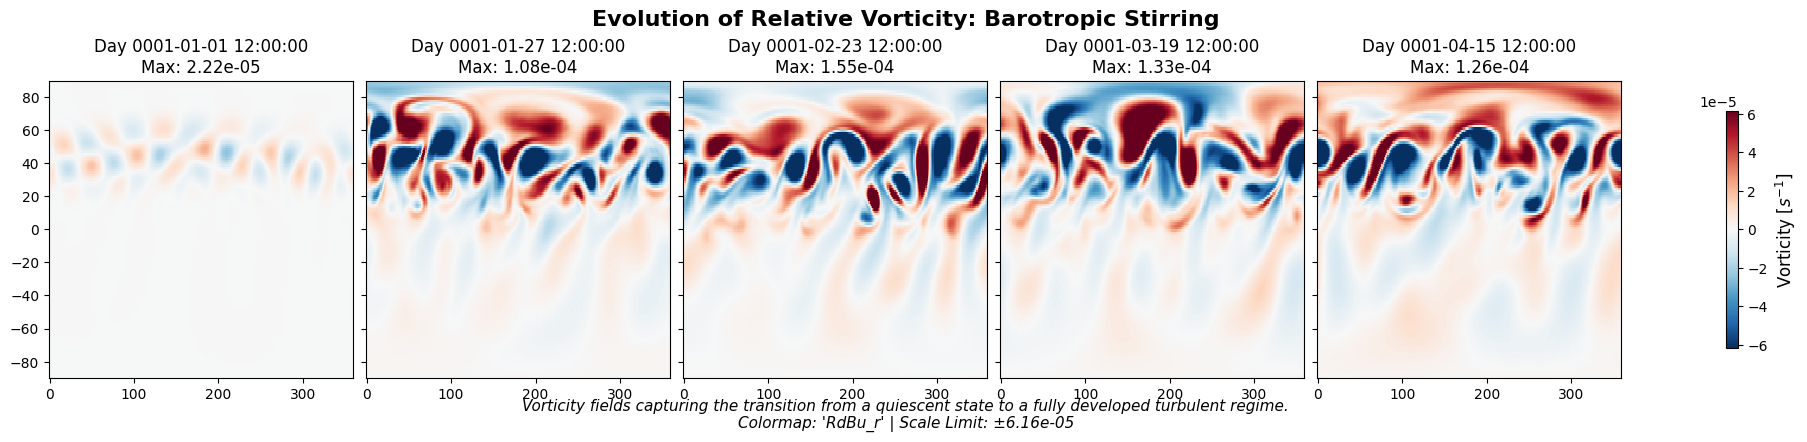

In [18]:
plot_variable_evolution(
    data_array=ds.vor, 
    slices=selected_indices,
    units="Vorticity [$s^{-1}$]",
    title="Evolution of Relative Vorticity: Barotropic Stirring",
    description="Vorticity fields capturing the transition from a quiescent state to a fully developed turbulent regime.",
    cmap="RdBu_r",
    robust_scaling=True
)

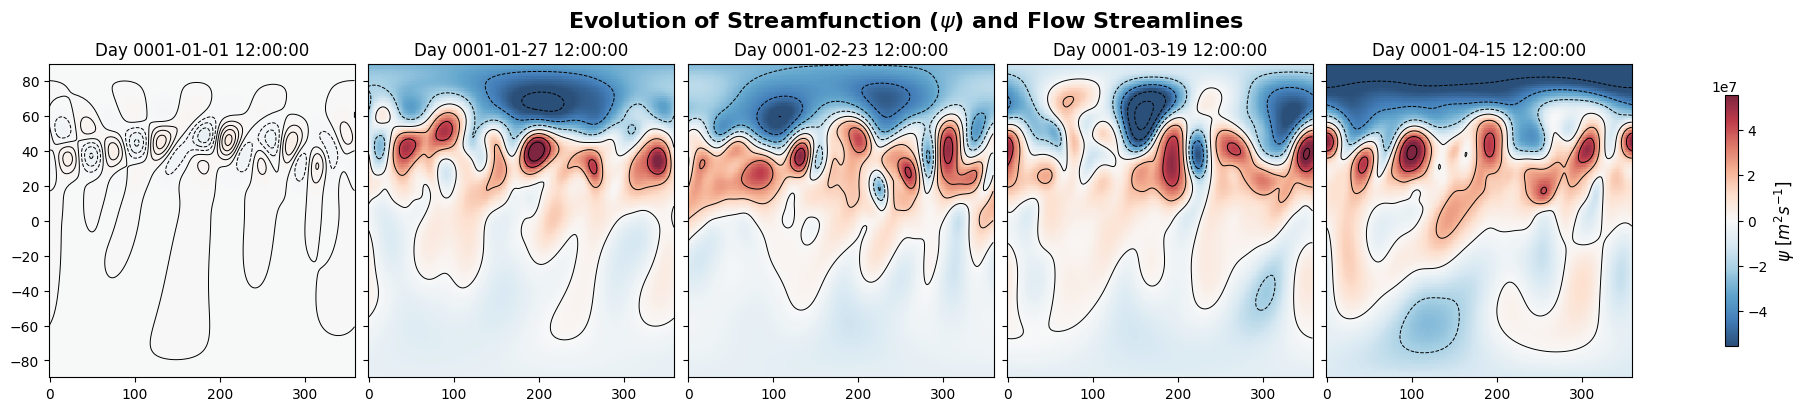

In [19]:
plot_streamfunction_evolution(
    data_array=ds.stream, 
    slices=selected_indices,
    contour_levels=10,
    title=r"Evolution of Streamfunction ($\psi$) and Flow Streamlines",
    robust_scaling=True
)

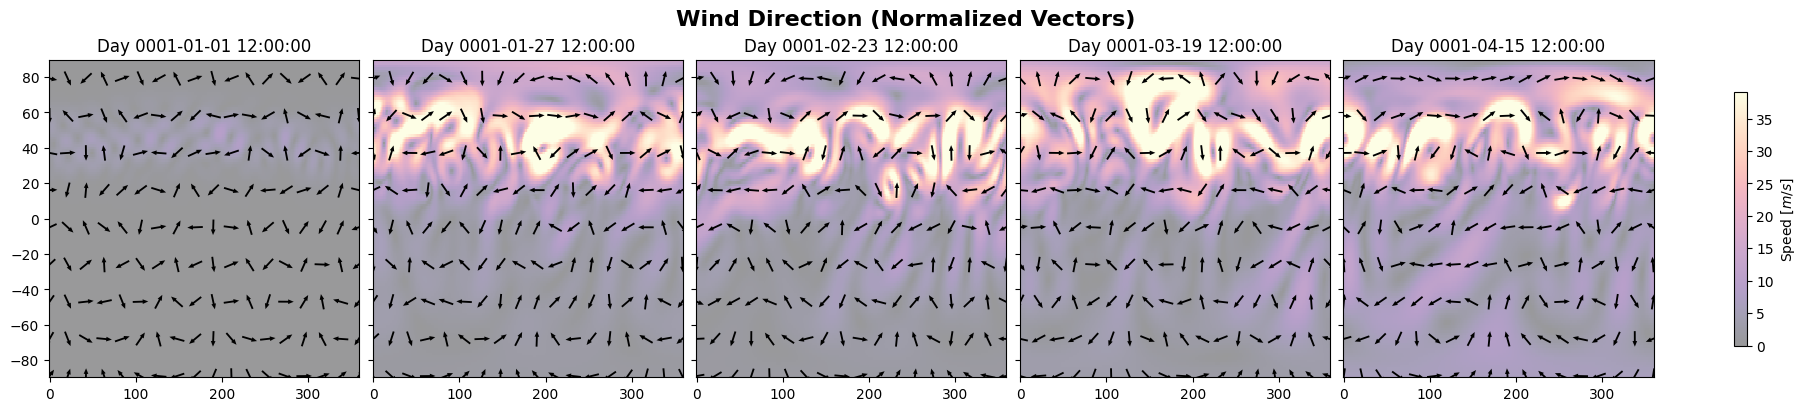

In [20]:
plot_velocity_direction(ds, slices=selected_indices, subsample=15)